In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

X = df.select_dtypes(include=["number"]).copy()
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(300, 8)

Après sélection des variables numériques et prétraitement (imputation par la médiane puis standardisation), le jeu de données obtenu comporte 300 observations décrites par 8 variables quantitatives. Cette matrice normalisée constitue l’entrée des analyses statistiques et des modèles de Machine Learning réalisés par la suite.

In [3]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

X_tsne[:5]

array([[11.241733  , -3.3562706 ],
       [ 9.78201   ,  0.87946266],
       [17.283047  , -1.2637584 ],
       [ 7.3038006 , -7.058923  ],
       [20.082563  ,  1.0286565 ]], dtype=float32)

Afin d’explorer la structure non linéaire des données, une réduction de dimension par t-SNE a été appliquée sur les variables standardisées. Les 300 observations ont été projetées dans un espace bidimensionnel, permettant une visualisation des similarités entre individus. Dans cette représentation, la proximité entre points reflète la similarité des profils, ce qui peut révéler l’existence de groupes ou de structures latentes dans les données.

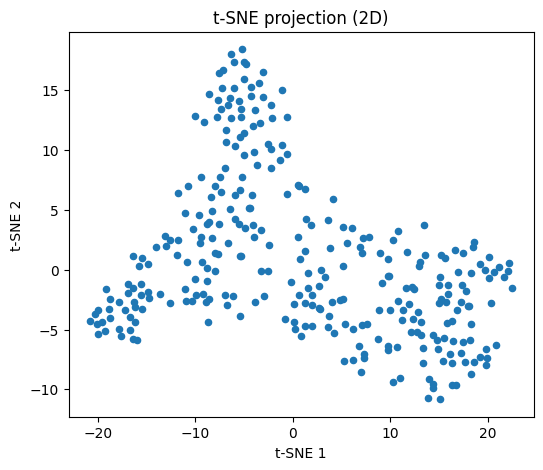

In [4]:
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection (2D)")
plt.show()

La projection t-SNE met en évidence l’existence de plusieurs regroupements d’observations dans l’espace réduit, suggérant une structure latente dans les données. Certains clusters apparaissent relativement bien séparés, tandis que d’autres zones présentent davantage de chevauchement, indiquant des profils intermédiaires. Cette organisation confirme l’intérêt d’appliquer des méthodes de clustering afin d’identifier des typologies d’individus.

In [6]:
out = pd.DataFrame(X_tsne, columns=["x", "y"])
out.to_csv("../outputs/tsne_2d.csv", index=False)
print("Exported to outputs/tsne_2d.csv")

Exported to outputs/tsne_2d.csv
